<table width="100%" cellpadding="0" cellspacing="0" style="border-collapse:separate; border-spacing:0; border-radius:18px; overflow:hidden; border:1px solid rgba(234,242,255,.10);">
  <tr>
    <td style="background: linear-gradient(135deg, #f7fbff 0%, #edf3fb 38%, #f3f6ff 62%, #ffeef2 100%); padding:0;">
      <div style="height:4px; background: linear-gradient(90deg, #28E0F0 0%, #DC2626 55%, #7BE9F7 100%);"></div>
      <div style="padding:24px 28px; text-align:center; color:#0b1535;">
        <div style="display:inline-block; padding:6px 12px; border-radius:999px; border:1px solid rgba(11,21,53,.18); color:rgba(11,21,53,.78); font-size:12px; font-weight:700; margin-bottom:12px; background:rgba(255,255,255,.65);">
          Decision-Support Analytics 
        </div>
        <div style="font-size:30px; font-weight:900; line-height:1.12; margin:0 0 10px;">
          <span style="color:#0EA5E9;">Heart Disease Risk</span>
          <span style="color:#DC2626;"> — </span>
          From Clinical Signals to Actionable Insights
        </div>
        <div style="font-size:16px; font-weight:650; color:rgba(11,21,53,.86);">
          EDA with clinical narratives • Feature engineering • Model benchmarking • Explainability (SHAP)
        </div>
        <div style="font-size:13px; margin-top:10px; color:rgba(11,21,53,.68);">
        </div>
      </div>
    </td>
  </tr>
</table>

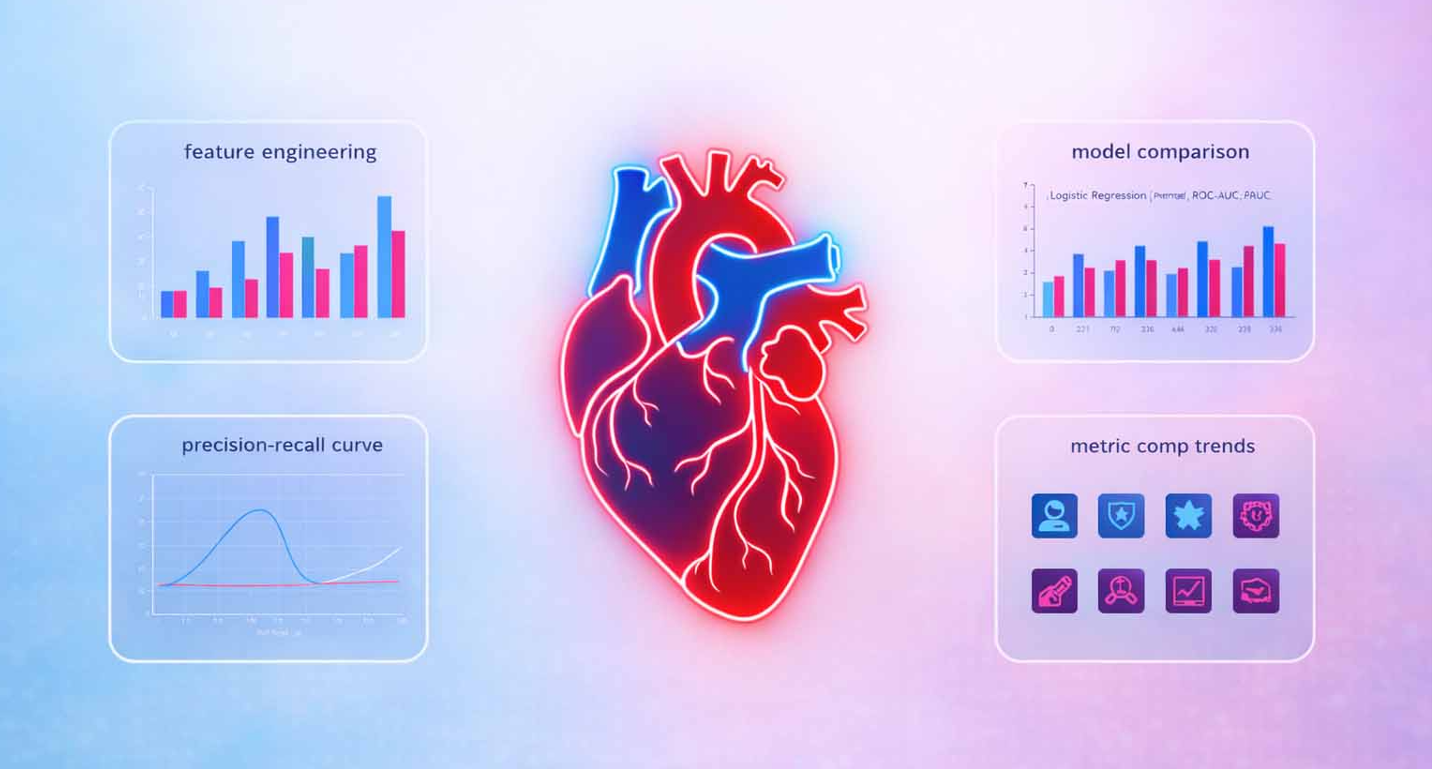

## Project Overview

Heart disease is a major contributor to preventable morbidity and mortality, making early and reliable risk stratification a high-impact capability for clinical decision support. This project leverages a structured clinical dataset comprising **918 patient records** and **12 variables** to translate routinely collected clinical signals into **actionable risk insights**.

The workflow applies standardized data quality handling, performs consistent exploratory data analysis (EDA), benchmarks multiple predictive models, and generates explainability artifacts to support transparency, stakeholder trust, and operational usability.

A key data-quality consideration is that the **Cholesterol** variable contains **172 zero-coded values**, which are commonly used as a missing-value proxy and must be handled explicitly to avoid biasing model learning. The target variable is **moderately imbalanced** (**HeartDisease=1: 55.3%**, **HeartDisease=0: 44.7%**), motivating performance evaluation beyond accuracy and emphasizing metrics such as **ROC-AUC**, **PR-AUC**, and **recall**.

---

## Dataset Features

- 🎂 **Age**: Patient age (years)  
- 🚻 **Sex**: Biological sex category  
- 💢 **ChestPainType**: Chest pain presentation category  
- 🩺 **RestingBP**: Resting blood pressure (mmHg)  
- 🧪 **Cholesterol**: Serum cholesterol level (mg/dL) *(note: contains zero-coded values)*  
- 🍬 **FastingBS**: Fasting blood sugar indicator (binary; typically >120 mg/dL)  
- 📈 **RestingECG**: Resting electrocardiogram results category  
- ❤️ **MaxHR**: Maximum heart rate achieved  
- 🏃‍♂️ **ExerciseAngina**: Exercise-induced angina indicator (Y/N)  
- 📉 **Oldpeak**: ST depression induced by exercise relative to rest  
- 🧭 **ST_Slope**: Slope of the peak exercise ST segment  
- 🎯 **HeartDisease (Target)**: Heart disease outcome (0 = No Disease, 1 = Disease)

# 1. Import Libraries

In [1]:
import re
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="invalid value encountered in less", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")
warnings.filterwarnings(
    "ignore",
    message=re.escape("X does not have valid feature names, but LGBMClassifier was fitted with feature names"),
    category=UserWarning
)
warnings.filterwarnings(
    "ignore",
    message=r"X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning
)

import os
import gc
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import uuid
from IPython.display import display, HTML
from matplotlib.colors import LinearSegmentedColormap

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    classification_report, precision_recall_curve, average_precision_score
)

from sklearn.inspection import permutation_importance

XGB_AVAILABLE = True
LGBM_AVAILABLE = True
try:
    from xgboost import XGBClassifier
except Exception:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBM_AVAILABLE = False

SHAP_AVAILABLE = True
SHAP_ERROR = None
try:
    import shap
except Exception as e:
    SHAP_AVAILABLE = False
    SHAP_ERROR = e

print("✅ Libraries loaded")
print(f"✅ XGBoost={XGB_AVAILABLE} | LightGBM={LGBM_AVAILABLE} | SHAP={SHAP_AVAILABLE}")
if not SHAP_AVAILABLE:
    print("   ↳ SHAP error:", SHAP_ERROR)

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


✅ Libraries loaded
✅ XGBoost=True | LightGBM=True | SHAP=True


In [2]:
HEART_BLUE = "#0EA5E9"   
HEART_RED  = "#E11D48"   

HEART_INDIGO = "#4F46E5"
HEART_VIOLET = "#8B5CF6"
HEART_CYAN   = "#22D3EE"

NEON_BLUE = "#28E0F0"
NEON_PINK = "#FF4FD8"

HEART_PALETTE = [HEART_INDIGO, HEART_BLUE, HEART_VIOLET, HEART_CYAN]

heart_cmap = LinearSegmentedColormap.from_list(
    "heart_cmap",
    [HEART_BLUE, "#ffffff", HEART_RED],
    N=256
)

THEME = {
    "bg": "#ffffff",
    "plot_bg": "#ffffff",
    "text": "#111827",
    "muted": "#6b7280",
    "grid": "#e5e7eb",

    "indigo": HEART_INDIGO,
    "sky":    HEART_BLUE,
    "violet": HEART_VIOLET,
    "cyan":   HEART_CYAN,

    "class_no":  HEART_BLUE,  
    "class_yes": HEART_RED,  
}

sns.set_theme(style="white")

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": THEME["bg"],
    "axes.facecolor": THEME["plot_bg"],
    "text.color": THEME["text"],
    "axes.labelcolor": THEME["text"],
    "axes.titlecolor": THEME["text"],
    "xtick.color": THEME["text"],
    "ytick.color": THEME["text"],
    "font.size": 11,
    "axes.edgecolor": THEME["grid"],
})

def section(title, subtitle=None):
    sub = (
        f'<div style="margin-top:6px; font-size:12.5px; font-weight:700; color:{THEME["text"]};">{subtitle}</div>'
        if subtitle else ""
    )
    display(HTML(f"""
    <div style="margin:18px 0 12px 0;">
      <div style="font-size:18px; font-weight:1000; color:{THEME["text"]};">{title}</div>
      {sub}
    </div>
    """))

def kpi_cards(items):
    cards = ""
    for it in items:
        cards += f"""
        <div style="flex:1; padding:16px 18px; border-radius:14px;
                    border:1px solid rgba(17,24,39,.10);
                    background:#ffffff; color:{THEME["text"]};">
          <div style="font-size:12px; font-weight:900;">{it['title']}</div>
          <div style="margin-top:10px; font-size:28px; font-weight:1000; color:{it.get('accent', THEME['text'])};">
            {it['value']}
          </div>
        </div>
        """
    display(HTML(f'<div style="display:flex; gap:12px; margin:10px 0 14px 0;">{cards}</div>'))

# DATAFRAME STYLING
def style_heart_table(styler):
    return (
        styler
        .set_table_styles(
            [
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "collapse"),
                        ("border-spacing", "0"),
                        ("border", "1px solid #e5e7eb"),
                        ("background-color", "white"),
                        ("width", "100%"),
                        ("max-width", "100%"),
                        ("margin-left", "auto"),
                        ("margin-right", "auto"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#e5e7eb"),
                        ("color", "#111827"),
                        ("font-weight", "900"),
                        ("border", "1px solid #d1d5db"),
                        ("padding", "8px 10px"),
                        ("white-space", "nowrap"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("border", "1px solid #d1d5db"),
                        ("padding", "7px 10px"),
                        ("color", "#111827"),
                        ("white-space", "normal"),
                        ("overflow-wrap", "anywhere"),
                        ("word-break", "break-word"),
                    ],
                },
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("text-align", "left"),
                        ("font-weight", "1000"),
                        ("color", "#111827"),
                        ("padding", "6px 0 10px 2px"),
                        ("font-size", "14px"),
                    ],
                },
            ]
        )
        .set_properties(**{"border": "1px solid #d1d5db"})
    )

def show_df(df, title=None, head=12, precision=4, heat=True):
    out = df.copy()
    if head is not None:
        out = out.head(head)

    sty = out.style.format(precision=precision)

    if heat:
        sty = sty.background_gradient(cmap=heart_cmap, axis=None)

    if title:
        sty = sty.set_caption(title)

    display(style_heart_table(sty))


def remove_spines(ax):
    for s in ["top", "right", "bottom", "left"]:
        ax.spines[s].set_visible(False)

def faint_dashed_ygrid(ax, alpha=0.35, lw=0.8):
    ax.grid(False)
    ax.yaxis.grid(True, linestyle="--", linewidth=lw, color=THEME["grid"], alpha=alpha)
    ax.xaxis.grid(False)

def ax_title(ax, text):
    ax.set_title(text, fontsize=13, fontweight="1000", color=THEME["text"], pad=14)

def hatch_panel(ax, alpha=0.05, hatch="///"):
    ax.set_facecolor("#ffffff")
    ax.patch.set_hatch(hatch)
    ax.patch.set_edgecolor("none")
    ax.patch.set_alpha(alpha)

print("✅ Theme ready (Heart-risk colors: blue vs pink-red + tables + charts)")

✅ Theme ready (Heart-risk colors: blue vs pink-red + tables + charts)


# 📊 2. DATA LOADING & INITIAL EXPLORATION

In [3]:


DATA_PATH = "/kaggle/input/heart-failure-prediction/heart.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

meta = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Duplicates"],
    "Value": [df.shape[0], df.shape[1], int(df.duplicated().sum())]
})

colnames = pd.DataFrame({"column": df.columns.tolist()})

dtypes_df = df.dtypes.rename("dtype").reset_index().rename(columns={"index":"column"})

basic_stats = df.describe(include="all").T.reset_index().rename(columns={"index":"column"})

missing_df = df.isnull().sum().rename("missing_count").reset_index().rename(columns={"index":"column"})

chol_zero = int((df["Cholesterol"] == 0).sum())
dq = pd.DataFrame({
    "Field": ["Cholesterol"],
    "ZeroCount": [chol_zero],
    "Governance": ["Treat 0 as missing-proxy: add flag + replace with NaN + median imputation"]
})

target_counts = (
    df["HeartDisease"]
    .value_counts()
    .rename_axis("HeartDisease")
    .reset_index(name="count")
    .sort_values("HeartDisease")
)
target_counts["ratio"] = target_counts["count"] / target_counts["count"].sum()

kpi_cards([
    {"title":"Total Samples", "value":f"{len(df)}", "accent":THEME["indigo"]},
    {"title":"Disease Rate", "value":f"{df['HeartDisease'].mean()*100:.1f}%", "accent":THEME["violet"]},
    {"title":"Cholesterol=0 (Missing Proxy)", "value":f"{chol_zero}", "accent":THEME["sky"]},
])

def df_to_styled_html(dfx, precision=4, heat=True, head=None):
    out = dfx.copy()
    if head is not None:
        out = out.head(head)

    sty = out.style.format(precision=precision)
    if heat:
        sty = sty.background_gradient(cmap=heart_cmap, axis=None)

    sty = style_heart_table(sty)  
    return sty.to_html()

tabs = [
    ("Dataset Shape",       df_to_styled_html(meta,         precision=0, heat=True,  head=10)),
    ("Column Names",        df_to_styled_html(colnames,     precision=0, heat=True,  head=200)),
    ("Data Types",          df_to_styled_html(dtypes_df,    precision=0, heat=True,  head=200)),
    ("Basic Statistics",    df_to_styled_html(basic_stats,  precision=4, heat=False, head=60)),
    ("Missing Values",      df_to_styled_html(missing_df,   precision=0, heat=True,  head=200)),
    ("Data Quality",        df_to_styled_html(dq,           precision=0, heat=True,  head=10)),
    ("Target Distribution", df_to_styled_html(target_counts,precision=4, heat=True,  head=10)),
]

panel_id = f"tabpanel_{uuid.uuid4().hex[:8]}"

buttons_html = ""
panes_html = ""
for i, (label, html_table) in enumerate(tabs):
    active = "active" if i == 0 else ""
    pane_id = f"{panel_id}_pane_{i}"
    buttons_html += f'<button class="ht-tab {active}" onclick="openHeartTab_{panel_id}(event, \'{pane_id}\')">{label}</button>'
    panes_html += f'<div class="ht-pane {active}" id="{pane_id}">{html_table}</div>'

html = f"""
<div id="{panel_id}" class="ht-wrap">
  <div class="ht-tabs">
    {buttons_html}
  </div>

  <div class="ht-content">
    {panes_html}
  </div>
</div>

<style>
  /* container */
  #{panel_id}.ht-wrap {{
    margin-top: 6px;
    border: 1px solid rgba(17,24,39,.10);
    border-radius: 12px;
    overflow: hidden;
    background: #ffffff;
  }}

  /* tabs row */
  #{panel_id} .ht-tabs {{
    display: flex;
    flex-wrap: wrap;
    gap: 6px;
    padding: 10px 10px;
    border-bottom: 1px solid rgba(17,24,39,.10);
    background: #ffffff;
  }}

  /* tab buttons */
  #{panel_id} .ht-tab {{
    appearance: none;
    border: 1px solid rgba(17,24,39,.15);
    background: #ffffff;
    color: #111827;
    font-weight: 900;
    font-size: 12px;
    padding: 6px 10px;
    border-radius: 10px;
    cursor: pointer;
    line-height: 1.1;
    user-select: none;
  }}
  #{panel_id} .ht-tab:hover {{
    border-color: rgba(17,24,39,.25);
  }}
  #{panel_id} .ht-tab.active {{
    background: rgba(79,70,229,.08);
    border-color: rgba(79,70,229,.35);
  }}

  /* content area: keep inside card + allow horizontal scroll if required */
  #{panel_id} .ht-content {{
    padding: 10px 12px 14px 12px;
    background: #ffffff;
    max-width: 100%;
    overflow-x: auto;
    overflow-y: hidden;
  }}

  /* panes */
  #{panel_id} .ht-pane {{
    display: none;
    max-width: 100%;
  }}
  #{panel_id} .ht-pane.active {{
    display: block;
  }}

  /* enforce table fit */
  #{panel_id} table {{
    width: 100% !important;
    max-width: 100% !important;
    table-layout: auto;
    font-size: 12px;
  }}

  /* force ALL text black */
  #{panel_id} table, #{panel_id} th, #{panel_id} td {{
    color: #111827 !important;
  }}

  /* prevent wide columns from pushing layout */
  #{panel_id} th, #{panel_id} td {{
    white-space: normal !important;
    overflow-wrap: anywhere !important;
    word-break: break-word !important;
  }}
</style>

<script>
function openHeartTab_{panel_id}(evt, paneId) {{
  const root = document.getElementById("{panel_id}");

  const panes = root.getElementsByClassName("ht-pane");
  for (let i = 0; i < panes.length; i++) {{
    panes[i].classList.remove("active");
  }}

  const tabs = root.getElementsByClassName("ht-tab");
  for (let i = 0; i < tabs.length; i++) {{
    tabs[i].classList.remove("active");
  }}

  document.getElementById(paneId).classList.add("active");
  evt.currentTarget.classList.add("active");
}}
</script>
"""

display(HTML(html))

# 🎨 3. EXPLORATORY DATA ANALYSIS (EDA)

# 3.1 Target Variable Analysis

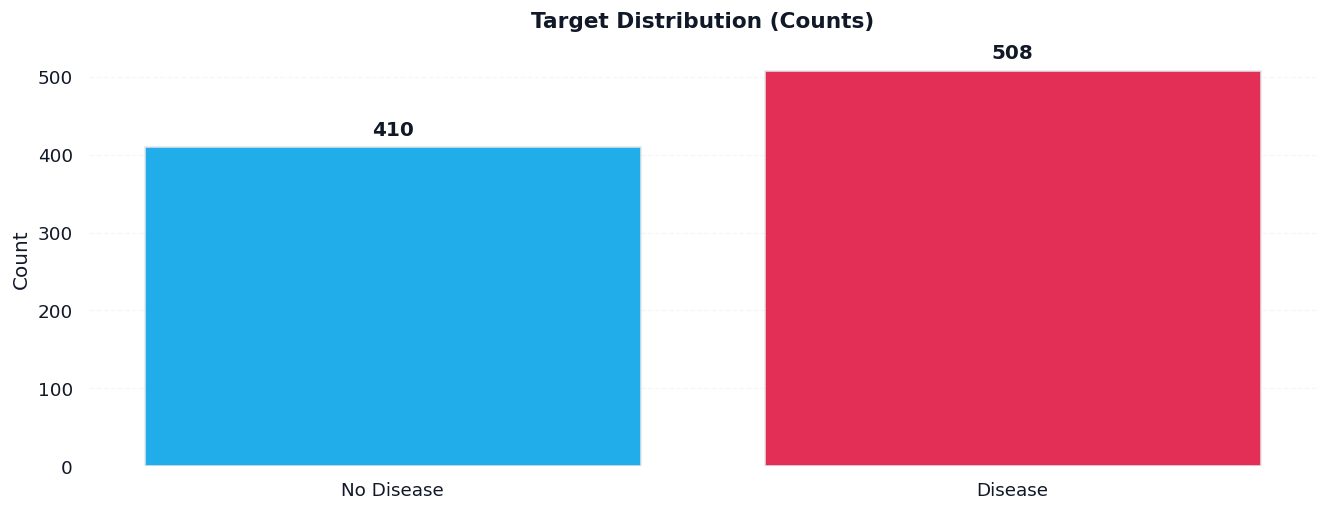

In [4]:
def plot_target_distribution(df):
    vc = df["HeartDisease"].value_counts().sort_index()
    c0, c1 = int(vc.get(0, 0)), int(vc.get(1, 0))

    fig, ax = plt.subplots(figsize=(11.2, 4.4))

    hatch_panel(ax, alpha=0.05, hatch="///")

    ax.bar(
        ["No Disease", "Disease"],
        [c0, c1],
        color=[THEME["class_no"], THEME["class_yes"]],   
        alpha=0.92,
        edgecolor=THEME["grid"],
        linewidth=1.0
    )

    ax_title(ax, "Target Distribution (Counts)")
    ax.set_ylabel("Count")

    top = max(c0, c1)
    for i, v in enumerate([c0, c1]):
        ax.text(
            i, v + top * 0.03,
            f"{v}",
            ha="center",
            fontweight="1000",
            color=THEME["text"],
            fontsize=12
        )

    faint_dashed_ygrid(ax, alpha=0.35, lw=0.8)
    remove_spines(ax)
    plt.tight_layout()
    plt.show()

plot_target_distribution(df)

# 3.2 Numerical Features Analysis

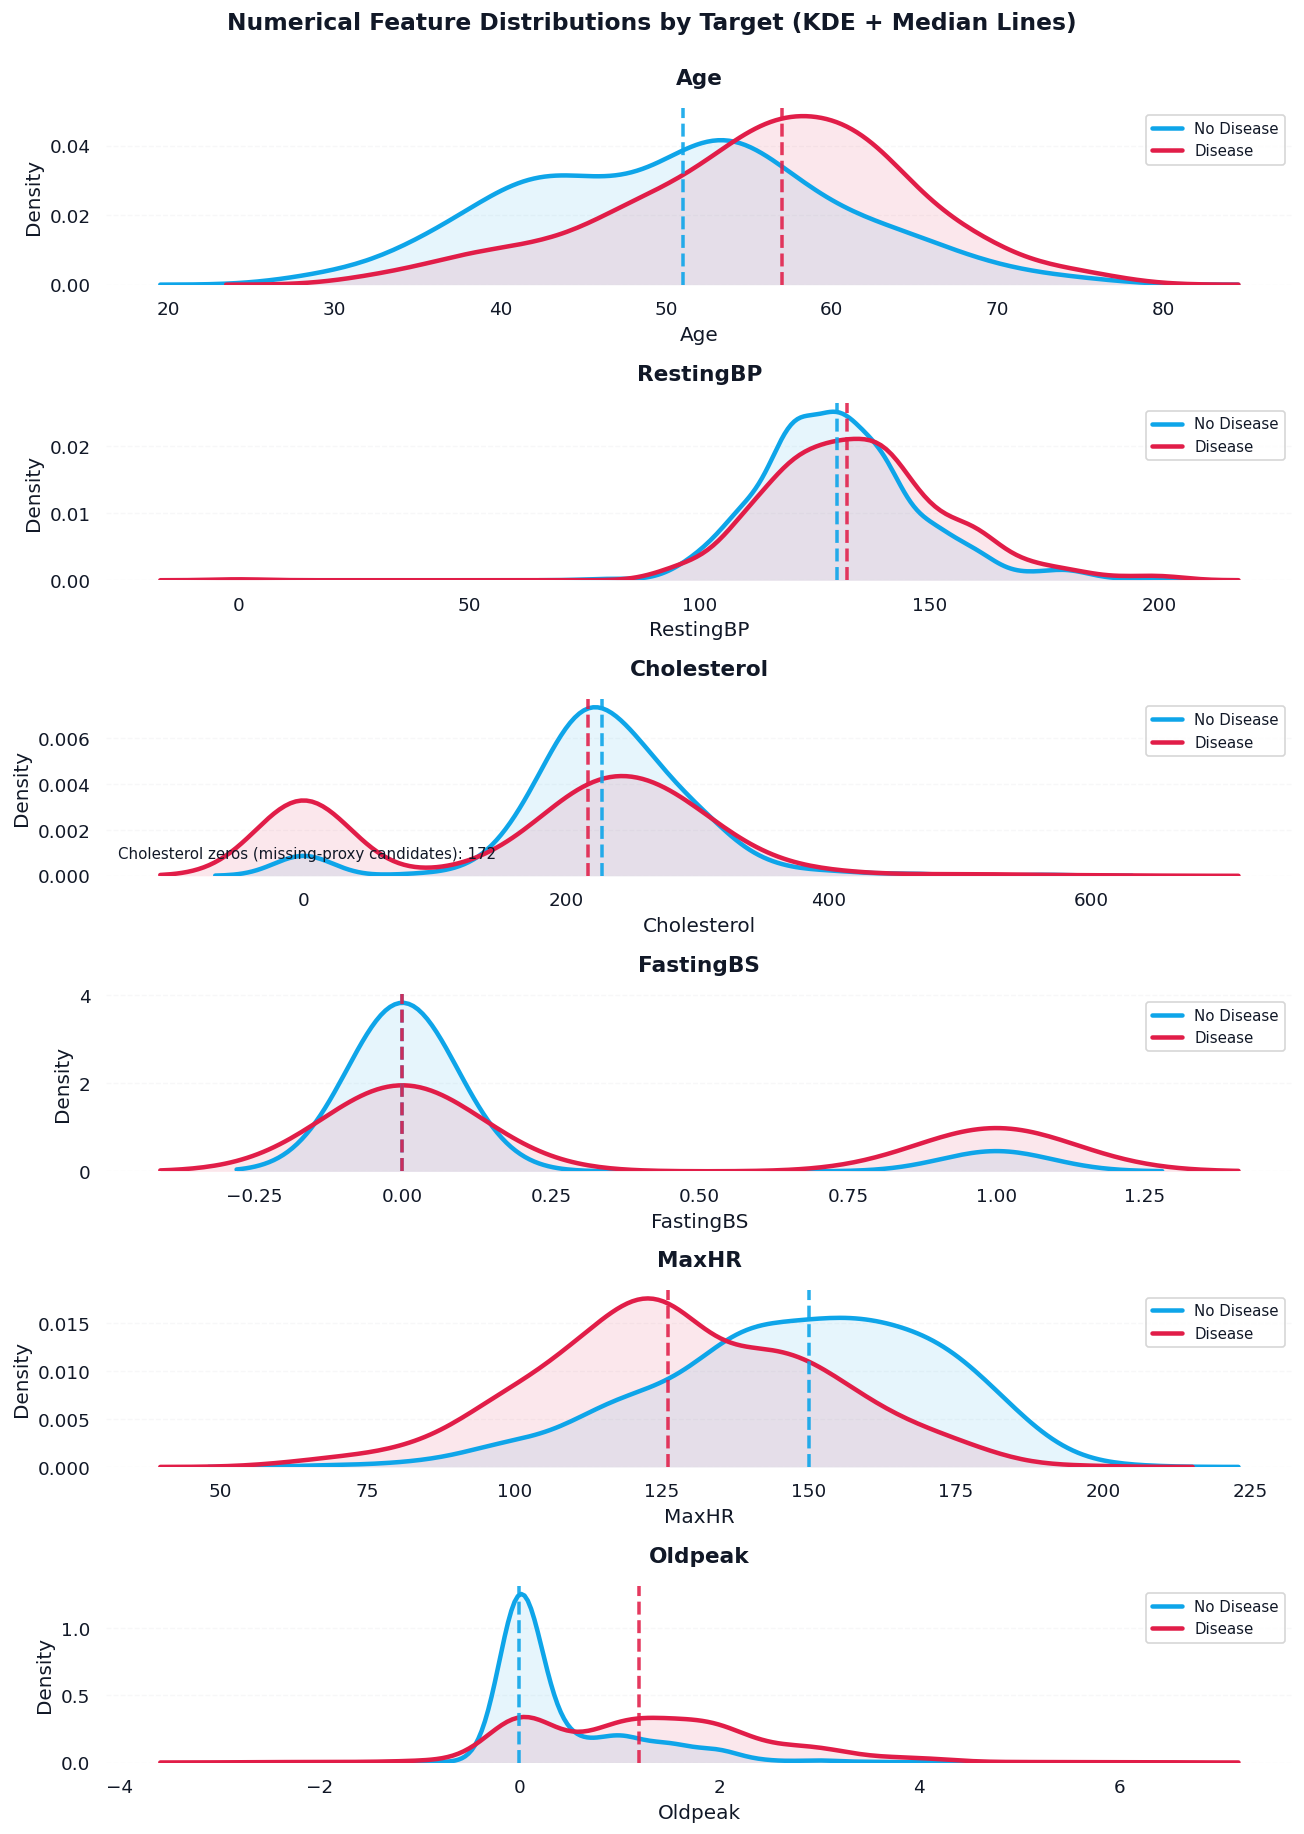

In [5]:
NUM_COLS = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

def plot_kde_median_stack(df, cols=NUM_COLS):
    n = len(cols)

    fig, axes = plt.subplots(n, 1, figsize=(11.0, 2.55*n))
    fig.subplots_adjust(hspace=3)

    c_no  = THEME.get("class_no", "#0EA5E9")  
    c_yes = THEME.get("class_yes", "#E11D48") 

    for i, col in enumerate(cols):
        ax = axes[i]
        x0 = df.loc[df["HeartDisease"] == 0, col].dropna()
        x1 = df.loc[df["HeartDisease"] == 1, col].dropna()

        ax.set_facecolor("#ffffff")
        ax.patch.set_edgecolor("none")
        ax.patch.set_alpha(0.05)

        sns.kdeplot(x=x0, ax=ax, color=c_no,  linewidth=2.7, fill=False, label="No Disease")
        sns.kdeplot(x=x1, ax=ax, color=c_yes, linewidth=2.7, fill=False, label="Disease")

        l0 = ax.lines[-2]  
        l1 = ax.lines[-1]  

        ax.fill_between(l0.get_xdata(), l0.get_ydata(), 0,
                        facecolor=c_no, alpha=0.10, linewidth=0)
        ax.fill_between(l1.get_xdata(), l1.get_ydata(), 0,
                        facecolor=c_yes, alpha=0.10, linewidth=0)

        ax.fill_between(l0.get_xdata(), l0.get_ydata(), 0,
                        facecolor="none", edgecolor=c_no, linewidth=0.0, alpha=0.20)
        ax.fill_between(l1.get_xdata(), l1.get_ydata(), 0,
                        facecolor="none", edgecolor=c_yes, linewidth=0.0, alpha=0.20)

        if len(x0) > 0:
            ax.axvline(np.median(x0), color=c_no,  linestyle="--", linewidth=2.1, alpha=0.90)
        if len(x1) > 0:
            ax.axvline(np.median(x1), color=c_yes, linestyle="--", linewidth=2.1, alpha=0.88)

        ax_title(ax, col)
        ax.set_ylabel("Density")
        ax.set_xlabel(col)

        faint_dashed_ygrid(ax, alpha=0.30, lw=0.8)
        remove_spines(ax)

        ax.legend(loc="upper right", frameon=True, fontsize=9)

        if col == "Cholesterol":
            zc = int((df["Cholesterol"] == 0).sum())
            ax.text(
                0.01, 0.10,
                f"Cholesterol zeros (missing-proxy candidates): {zc}",
                transform=ax.transAxes,
                fontsize=9,
                color=THEME["text"]
            )

    fig.suptitle(
        "Numerical Feature Distributions by Target (KDE + Median Lines)",
        fontsize=14, fontweight="1000", color=THEME["text"], y=0.997
    )
    plt.tight_layout()
    plt.show()

plot_kde_median_stack(df)

In [6]:
g = df.groupby("HeartDisease")[NUM_COLS].agg(["mean", "median", "std"])

g.columns = [f"{feat}_{stat}" for feat, stat in g.columns]
g = g.reset_index()

g0 = g[g["HeartDisease"] == 0].drop(columns=["HeartDisease"]).copy()
g1 = g[g["HeartDisease"] == 1].drop(columns=["HeartDisease"]).copy()

rows = []
for feat in NUM_COLS:
    rows.append({
        "Feature": feat,
        "NoDisease_mean":   float(g0[f"{feat}_mean"].iloc[0]),
        "NoDisease_median": float(g0[f"{feat}_median"].iloc[0]),
        "NoDisease_std":    float(g0[f"{feat}_std"].iloc[0]),
        "Disease_mean":     float(g1[f"{feat}_mean"].iloc[0]),
        "Disease_median":   float(g1[f"{feat}_median"].iloc[0]),
        "Disease_std":      float(g1[f"{feat}_std"].iloc[0]),
        "Mean_Delta(1-0)":  float(g1[f"{feat}_mean"].iloc[0] - g0[f"{feat}_mean"].iloc[0]),
    })

num_summary_wide = pd.DataFrame(rows)

show_df(num_summary_wide, "Numerical Summary by Target (Wide View)", head=60, precision=3)

,Feature,NoDisease_mean,NoDisease_median,NoDisease_std,Disease_mean,Disease_median,Disease_std,Mean_Delta(1-0)
0,Age,50.551,51.000,9.445,55.900,57.000,8.727,5.348
1,RestingBP,130.180,130.000,16.500,134.185,132.000,19.829,4.005
2,Cholesterol,227.122,227.000,74.635,175.941,217.000,126.391,-51.181
3,FastingBS,0.107,0.000,0.310,0.335,0.000,0.472,0.227
4,MaxHR,148.151,150.000,23.288,127.656,126.000,23.387,-20.496
5,Oldpeak,0.408,0.000,0.700,1.274,1.200,1.152,0.866


# 3.3 Categorical Features Analysis

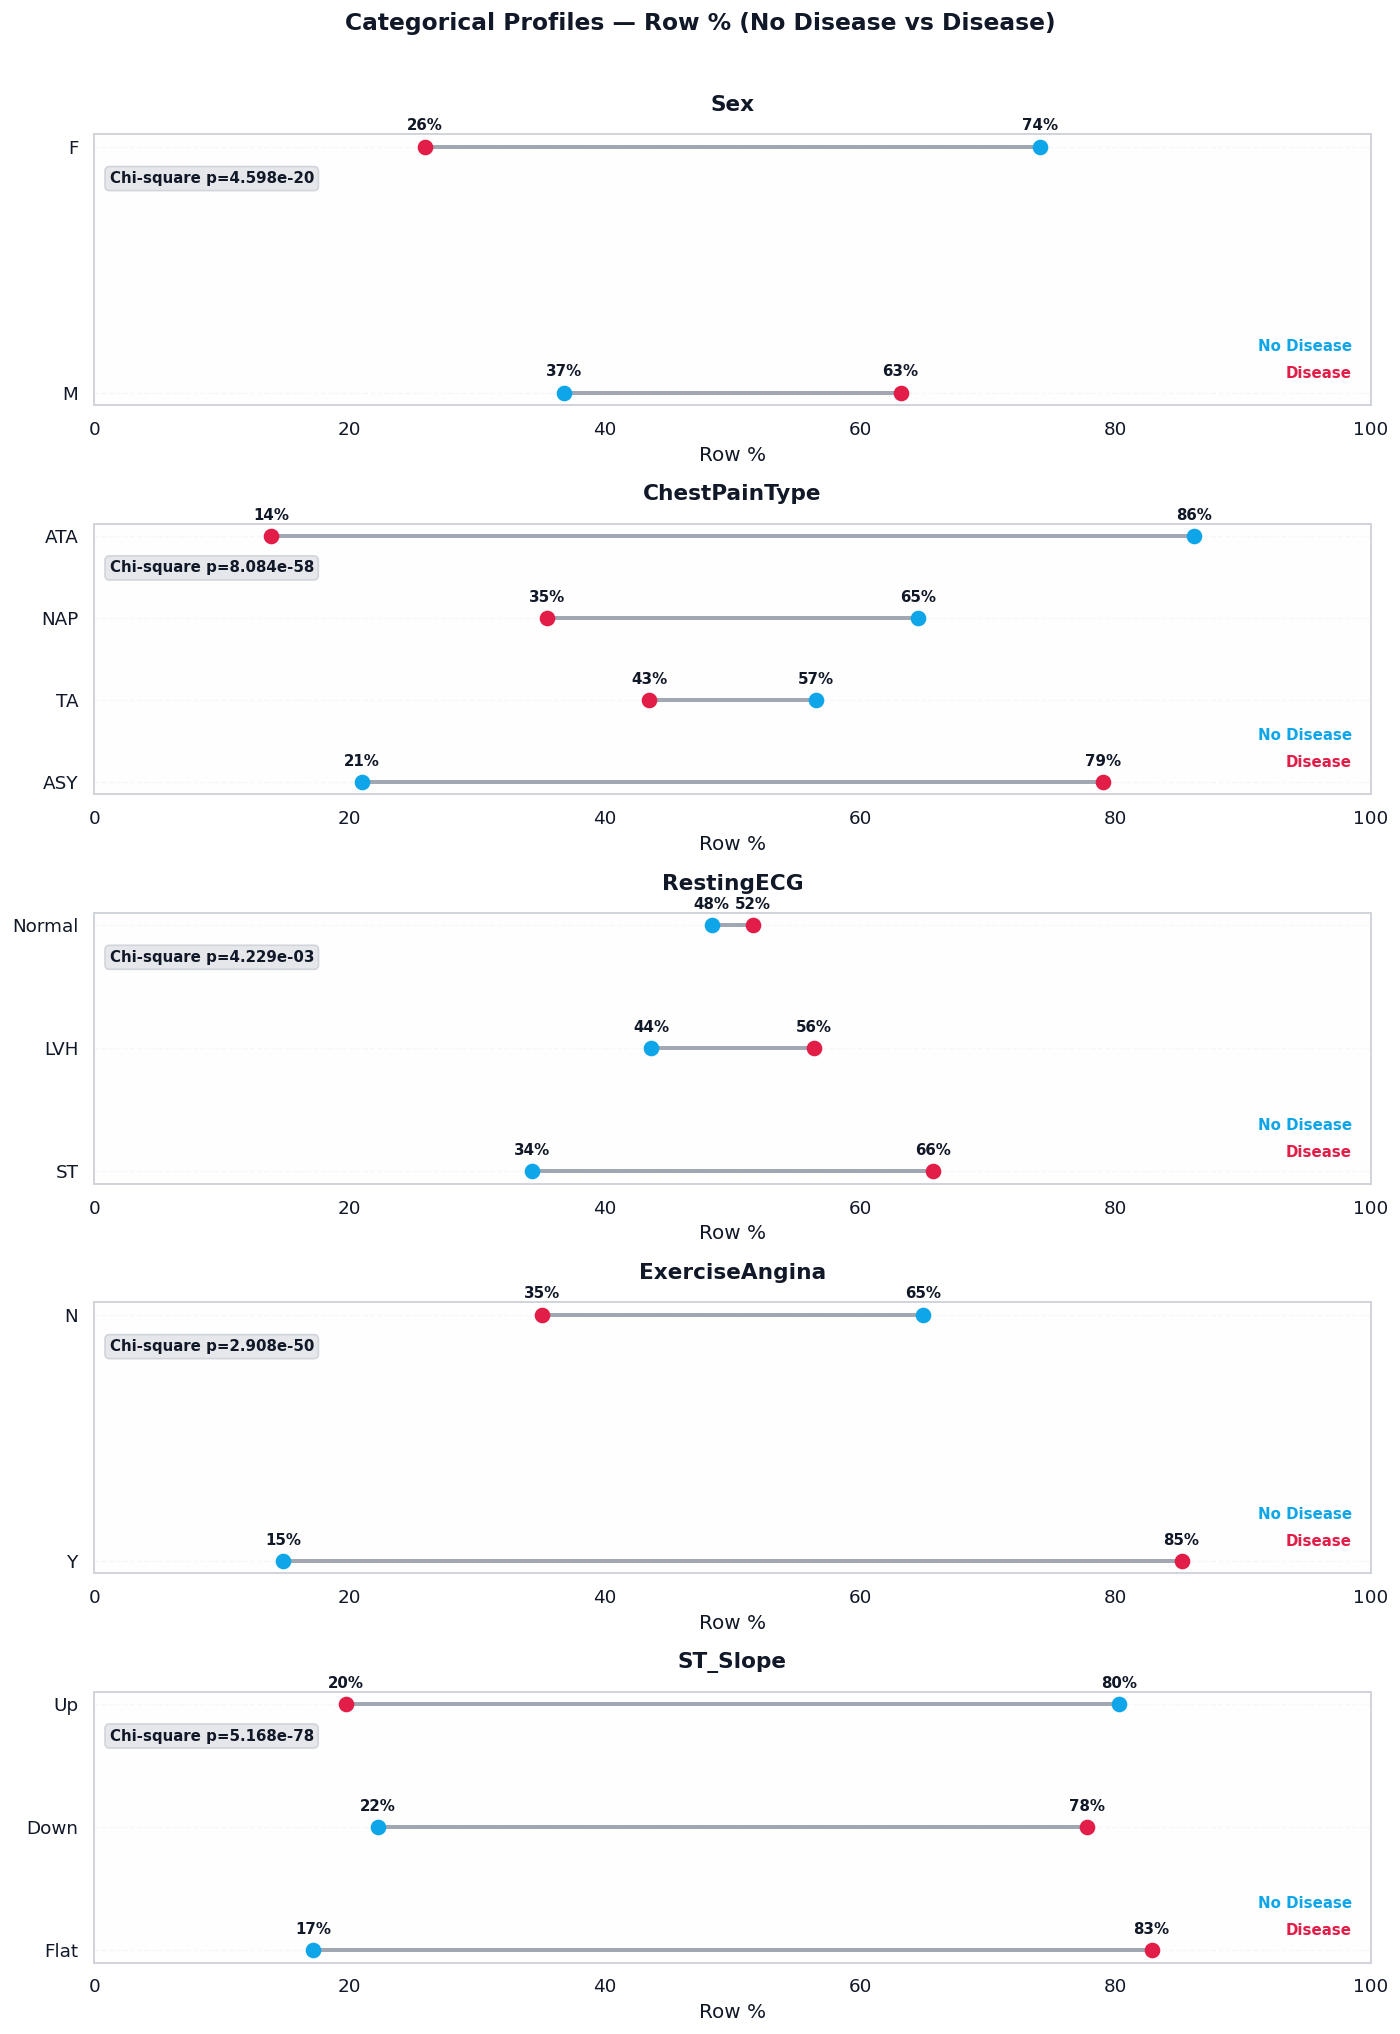

In [7]:
CAT_COLS = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

def plot_categorical_profiles(df, cols=CAT_COLS):
    n = len(cols)
    fig, axes = plt.subplots(n, 1, figsize=(11.8, 3.40 * n))
    fig.subplots_adjust(hspace=1.75)

    c_no  = THEME.get("class_no", "#0EA5E9")
    c_yes = THEME.get("class_yes", "#E11D48")

    for i, col in enumerate(cols):
        ax = axes[i]

        ax.set_facecolor("#f3f4f6")
        ax.patch.set_hatch("///")
        ax.patch.set_edgecolor("none")
        ax.patch.set_alpha(0.08)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("#d1d5db")
            spine.set_linewidth(1.2)

        ct_abs = pd.crosstab(df[col], df["HeartDisease"])
        ct_pct = pd.crosstab(df[col], df["HeartDisease"], normalize="index") * 100
        chi2, p, dof, _ = chi2_contingency(ct_abs)

        disease_pct = ct_pct.get(1, pd.Series([0]*len(ct_pct), index=ct_pct.index))
        order = disease_pct.sort_values(ascending=False).index.tolist()

        y_pos = np.arange(len(order))
        nd = ct_pct.loc[order, 0].values if 0 in ct_pct.columns else np.zeros(len(order))
        ds = ct_pct.loc[order, 1].values if 1 in ct_pct.columns else np.zeros(len(order))

        for yi, a, b in zip(y_pos, nd, ds):
            ax.plot([a, b], [yi, yi], color="#9ca3af", linewidth=2.4, alpha=0.95, zorder=1)

            ax.scatter(a, yi, s=70, color=c_no,  zorder=3)
            ax.scatter(b, yi, s=70, color=c_yes, zorder=3)

            ax.annotate(
                f"{a:.0f}%",
                xy=(a, yi),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="900",
                color=THEME["text"]
            )

            ax.annotate(
                f"{b:.0f}%",
                xy=(b, yi),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="900",
                color=THEME["text"]
            )

        ax.set_yticks(y_pos)
        ax.set_yticklabels(order, color=THEME["text"])
        ax.set_xlim(0, 100)
        ax.set_xlabel("Row %")

        ax_title(ax, col)
        faint_dashed_ygrid(ax, alpha=0.28, lw=0.8)

        ax.text(
            0.012, 0.82, f"Chi-square p={p:.3e}",
            transform=ax.transAxes,
            fontsize=9,
            fontweight="800",
            color=THEME["text"],
            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="#e5e7eb",
                edgecolor="#d1d5db",
                linewidth=1.0
            )
        )

        ax.text(0.985, 0.20, "No Disease",
                transform=ax.transAxes, ha="right",
                fontsize=9, fontweight="900",
                color=c_no)

        ax.text(0.985, 0.10, "Disease",
                transform=ax.transAxes, ha="right",
                fontsize=9, fontweight="900",
                color=c_yes)

    fig.suptitle(
        "Categorical Profiles — Row % (No Disease vs Disease)",
        fontsize=14,
        fontweight="1000",
        color=THEME["text"],
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()


plot_categorical_profiles(df)

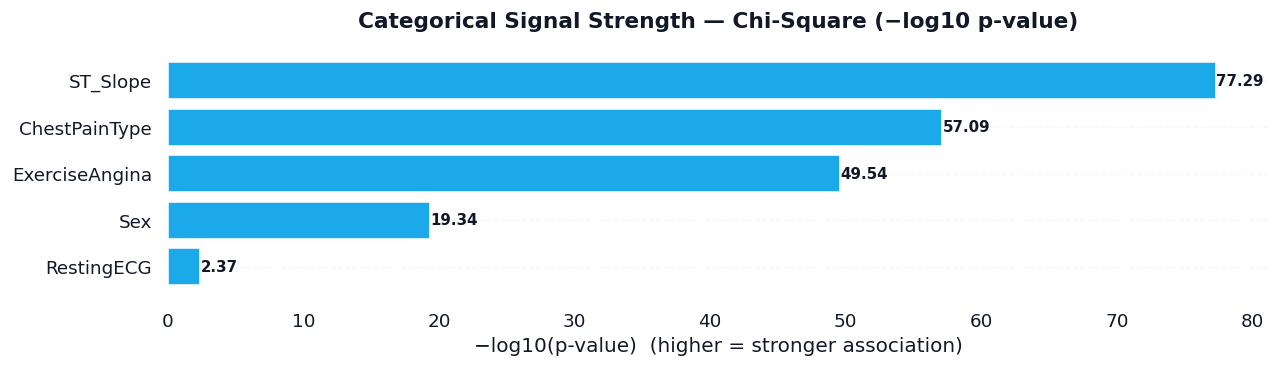

,Feature,Chi2,p_value,Significant(p<0.05)
0,ST_Slope,355.918443,0.000000,True
1,ChestPainType,268.067239,0.000000,True
2,ExerciseAngina,222.259383,0.000000,True
3,Sex,84.145101,0.000000,True
4,RestingECG,10.931469,0.004229,True


In [8]:
chi_rows = []
for col in CAT_COLS:
    ct_abs = pd.crosstab(df[col], df["HeartDisease"])
    chi2, p, dof, _ = chi2_contingency(ct_abs)
    chi_rows.append({"Feature": col, "Chi2": chi2, "p_value": p, "Significant(p<0.05)": p < 0.05})

chi_df = pd.DataFrame(chi_rows).sort_values("p_value").reset_index(drop=True)

chi_df["neglog10_p"] = -np.log10(np.clip(chi_df["p_value"].values, 1e-300, 1.0))

fig, ax = plt.subplots(figsize=(10.8, 3.2))

ax.set_facecolor("#ffffff")
ax.patch.set_hatch("///")
ax.patch.set_edgecolor("none")
ax.patch.set_alpha(0.06)

bar_color = THEME.get("violet", "#8B5CF6")
sig_color = THEME.get("sky", "#0EA5E9")

plot_df = chi_df.sort_values("neglog10_p", ascending=True)

colors = [sig_color if s else bar_color for s in plot_df["Significant(p<0.05)"].values]
ax.barh(plot_df["Feature"], plot_df["neglog10_p"], color=colors, alpha=0.95)

ax_title(ax, "Categorical Signal Strength — Chi-Square (−log10 p-value)")
ax.set_xlabel("−log10(p-value)  (higher = stronger association)")
ax.set_ylabel("")

faint_dashed_ygrid(ax, alpha=0.28, lw=0.8) 
remove_spines(ax)

for y, v in enumerate(plot_df["neglog10_p"].values):
    ax.text(v + 0.05, y, f"{v:.2f}", va="center", fontsize=9, color=THEME["text"], fontweight="700")

plt.tight_layout()
plt.show()

chi_view = chi_df[["Feature", "Chi2", "p_value", "Significant(p<0.05)"]].copy()

display(HTML("""
<style>
/* Make the wrapper span full width */
.ht-full { width: 100%; }

/* Force the pandas table to use the available width */
.ht-full table { width: 100% !important; max-width: 100% !important; }

/* Slightly compact cells for better fit */
.ht-full th, .ht-full td { padding: 6px 10px !important; font-size: 12px !important; }

/* Keep text black */
.ht-full table, .ht-full th, .ht-full td { color: #111827 !important; }

/* Wrap long text safely */
.ht-full th, .ht-full td { white-space: normal !important; overflow-wrap: anywhere !important; }
</style>
"""))

sty = chi_view.head(10).style.format({"Chi2":"{:.6f}", "p_value":"{:.6f}"})
sty = sty.background_gradient(cmap=heart_cmap, axis=None)
sty = sty.set_caption("Chi-Square Test Results (Top 10)")
sty = style_heart_table(sty)

display(HTML(f"""
<div class="ht-full" style="display:flex; justify-content:center; width:100%; margin-top:10px;">
  <div style="width: min(1100px, 100%);">
    {sty.to_html()}
  </div>
</div>
"""))

# 3.4 Correlation Analysis

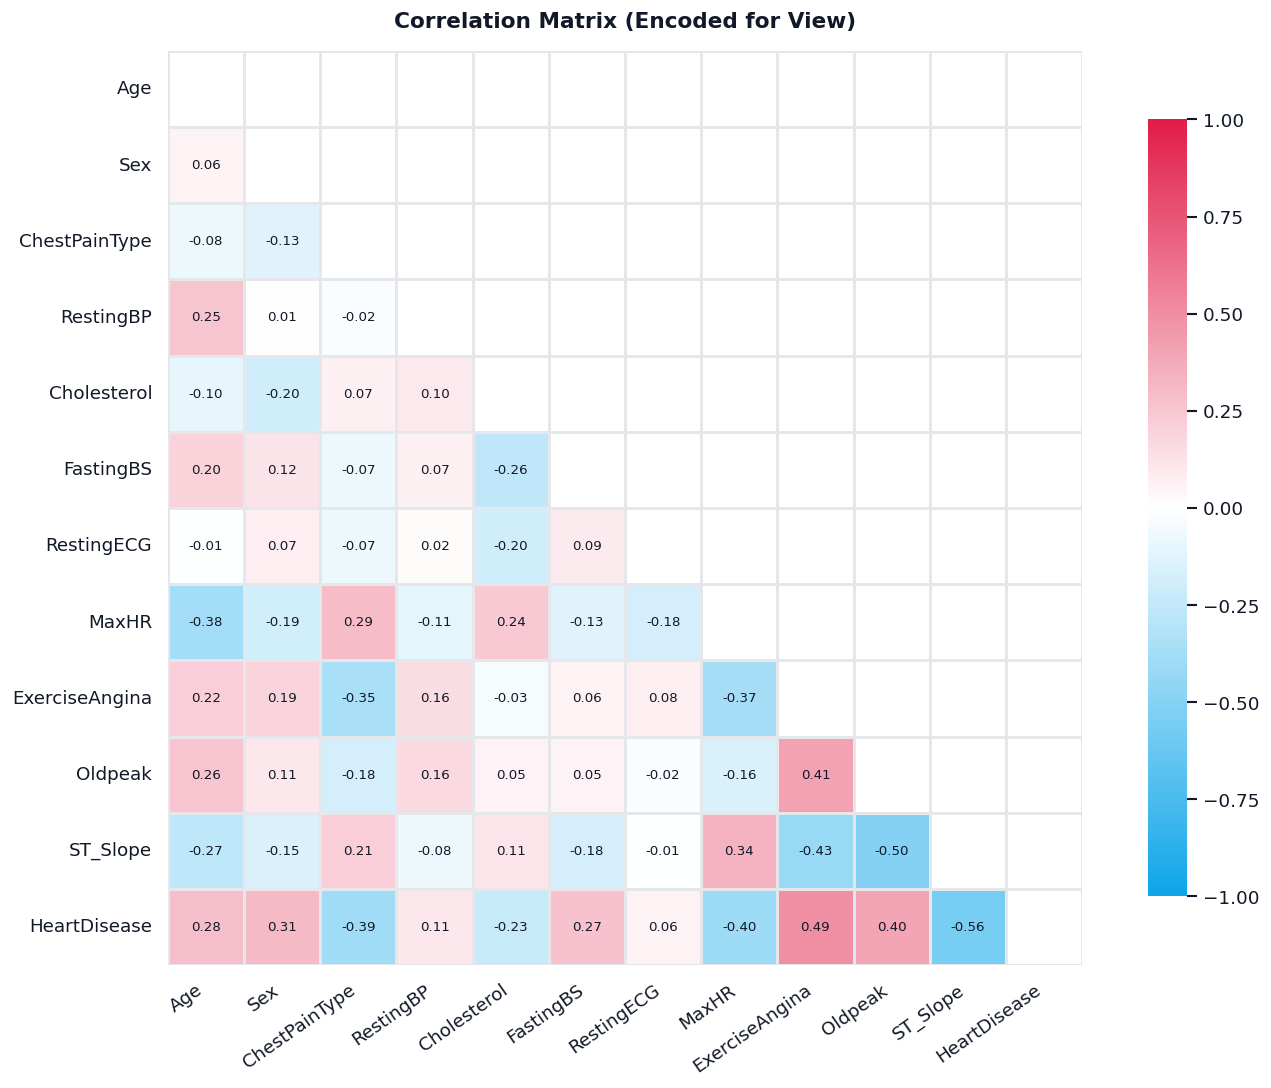

In [9]:
def correlation_analysis_theme(df, target="HeartDisease"):

    df_enc = df.copy()
    for c in df_enc.select_dtypes(include=["object", "category"]).columns:
        df_enc[c] = df_enc[c].astype("category").cat.codes

    corr = df_enc.corr(numeric_only=True)

    corr_cmap = LinearSegmentedColormap.from_list(
        "heart_corr",
        [THEME["class_no"], "#ffffff", THEME["class_yes"]],
        N=256
    )

    fig, ax = plt.subplots(figsize=(12.2, 9.2))

    ax.set_facecolor("#ffffff")
    ax.patch.set_hatch("///")
    ax.patch.set_edgecolor("none")
    ax.patch.set_alpha(0.05)
    
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        corr,
        mask=mask,
        cmap=corr_cmap,
        vmin=-1, vmax=1, center=0,
        square=True,
        linewidths=0.7,
        linecolor=THEME["grid"],
        cbar_kws={"shrink": 0.85},
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 8, "color": THEME["text"]},
        ax=ax
    )

    ax_title(ax, "Correlation Matrix (Encoded for View)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", color=THEME["text"])
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color=THEME["text"])

    remove_spines(ax)
    plt.tight_layout()
    plt.show()

correlation_analysis_theme(df, target="HeartDisease")

# 🔧 4. FEATURE ENGINEERING

In [10]:
def create_features(df):
    d = df.copy()

    # Governance: cholesterol zero proxy
    d["Cholesterol_ZeroFlag"] = (d["Cholesterol"] == 0).astype(int)
    d["Cholesterol"] = d["Cholesterol"].replace(0, np.nan)

    # Buckets
    d["AgeGroup"] = pd.cut(d["Age"], bins=[0, 40, 55, 70, 120], labels=["Young", "Middle", "Senior", "Elderly"])
    d["BPCategory"] = pd.cut(d["RestingBP"], bins=[-1, 120, 140, 400], labels=["Normal", "Elevated", "High"])
    d["HRCategory"] = pd.cut(d["MaxHR"], bins=[0, 100, 140, 260], labels=["Low", "Normal", "High"])
    d["CholesterolCategory"] = pd.cut(d["Cholesterol"], bins=[0, 200, 240, 2000], labels=["Normal", "Borderline", "High"])

    # Heuristic risk score
    d["RiskScore"] = (
        (d["Age"] > 55).astype(int) +
        (d["Cholesterol"] > 240).astype(int) +
        (d["RestingBP"] > 140).astype(int) +
        (d["FastingBS"] == 1).astype(int) +
        (d["ExerciseAngina"] == "Y").astype(int) +
        (d["ST_Slope"].isin(["Flat", "Down"])).astype(int)
    )

    # Interactions
    d["Age_Chol_Interaction"] = d["Age"] * d["Cholesterol"]
    d["HR_Age_Ratio"] = d["MaxHR"] / d["Age"].replace(0, np.nan)

    created = pd.DataFrame({"NewFeature": [
        "Cholesterol_ZeroFlag", "AgeGroup", "BPCategory", "HRCategory", "CholesterolCategory",
        "RiskScore", "Age_Chol_Interaction", "HR_Age_Ratio"
    ]})
    show_df(created, "Created Features", head=20, precision=0)
    return d

df_fe = create_features(df)

,NewFeature
0,Cholesterol_ZeroFlag
1,AgeGroup
2,BPCategory
3,HRCategory
4,CholesterolCategory
5,RiskScore
6,Age_Chol_Interaction
7,HR_Age_Ratio


# 🔄 5. DATA PREPROCESSING

In [11]:
X = df_fe.drop("HeartDisease", axis=1)
y = df_fe["HeartDisease"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

type_counts = pd.DataFrame({"Type": ["Numerical", "Categorical"], "Count": [len(numeric_cols), len(cat_cols)]})
show_df(type_counts, "Feature Type Counts", head=10, precision=0)

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

split_df = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Cols": [X_train.shape[1], X_test.shape[1]],
    "PositiveRate": [float(y_train.mean()), float(y_test.mean())]
})
show_df(split_df, "Train/Test Split", head=10, precision=4)

,Type,Count
0,Numerical,10
1,Categorical,9


,Split,Rows,Cols,PositiveRate
0,Train,734,19,0.5531
1,Test,184,19,0.5543


# 🤖 6. MODEL TRAINING - BASELINE MODELS

In [12]:
SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def compute_metrics(y_true, y_pred, y_proba=None):
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        out["ROC-AUC"] = roc_auc_score(y_true, y_proba)
        out["PR-AUC"] = average_precision_score(y_true, y_proba)
    else:
        out["ROC-AUC"] = np.nan
        out["PR-AUC"] = np.nan
    return out


def train_baseline(name, model):
    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])

    scoring = {
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    }
    cv_out = cross_validate(
        pipe,
        X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_metrics = {
        "CV_ROC-AUC_Mean": float(np.mean(cv_out["test_roc_auc"])),
        "CV_ROC-AUC_Std":  float(np.std(cv_out["test_roc_auc"])),
        "CV_PR-AUC_Mean":  float(np.mean(cv_out["test_pr_auc"])),
        "CV_PR-AUC_Std":   float(np.std(cv_out["test_pr_auc"])),
    }

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    test_metrics = compute_metrics(y_test, y_pred, y_proba)

    return {
        "name": name,
        "pipeline": pipe,
        "test": test_metrics,
        "cv": cv_metrics,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "cm": confusion_matrix(y_test, y_pred)
    }

models = [
    ("Logistic Regression",
     LogisticRegression(max_iter=6000, solver="liblinear", class_weight="balanced", random_state=SEED)),

    ("Random Forest",
     RandomForestClassifier(n_estimators=700, n_jobs=-1, random_state=SEED, class_weight="balanced_subsample")),

    ("Gradient Boosting",
     GradientBoostingClassifier(random_state=SEED)),
]

if XGB_AVAILABLE:
    models.append((
        "XGBoost",
        XGBClassifier(
            random_state=SEED,
            eval_metric="logloss",
            n_estimators=700,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            n_jobs=-1
        )
    ))

if LGBM_AVAILABLE:
    models.append((
        "LightGBM",
        LGBMClassifier(
            random_state=SEED,
            verbose=-1,
            n_jobs=-1,
            class_weight="balanced",
            n_estimators=900,
            learning_rate=0.03,
            num_leaves=63,
            subsample=0.9,
            colsample_bytree=0.9
        )
    ))

results = []
for name, model in models:
    r = train_baseline(name, model)
    results.append(r)

scorecard = pd.DataFrame([
    {"Model": r["name"], **r["test"], **r["cv"]}
    for r in results
])

scorecard = (
    scorecard
    .sort_values(["CV_PR-AUC_Mean", "CV_ROC-AUC_Mean", "PR-AUC", "ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

show_df(scorecard, "Model Comparison Table", head=30, precision=4)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,CV_ROC-AUC_Mean,CV_ROC-AUC_Std,CV_PR-AUC_Mean,CV_PR-AUC_Std
0,Logistic Regression,0.8804,0.9000,0.8824,0.8911,0.9261,0.9244,0.9271,0.0365,0.9325,0.0350
1,Random Forest,0.9022,0.8962,0.9314,0.9135,0.9350,0.9317,0.9243,0.0274,0.9232,0.0258
2,Gradient Boosting,0.8913,0.9020,0.9020,0.9020,0.9274,0.9278,0.9221,0.0204,0.9169,0.0227
3,XGBoost,0.8587,0.8800,0.8627,0.8713,0.9243,0.9174,0.9188,0.0250,0.9161,0.0252
4,LightGBM,0.8533,0.8788,0.8529,0.8657,0.9275,0.9338,0.9169,0.0279,0.9148,0.0345


# 📊 7. CV PR-AUC EXECUTIVE BAR

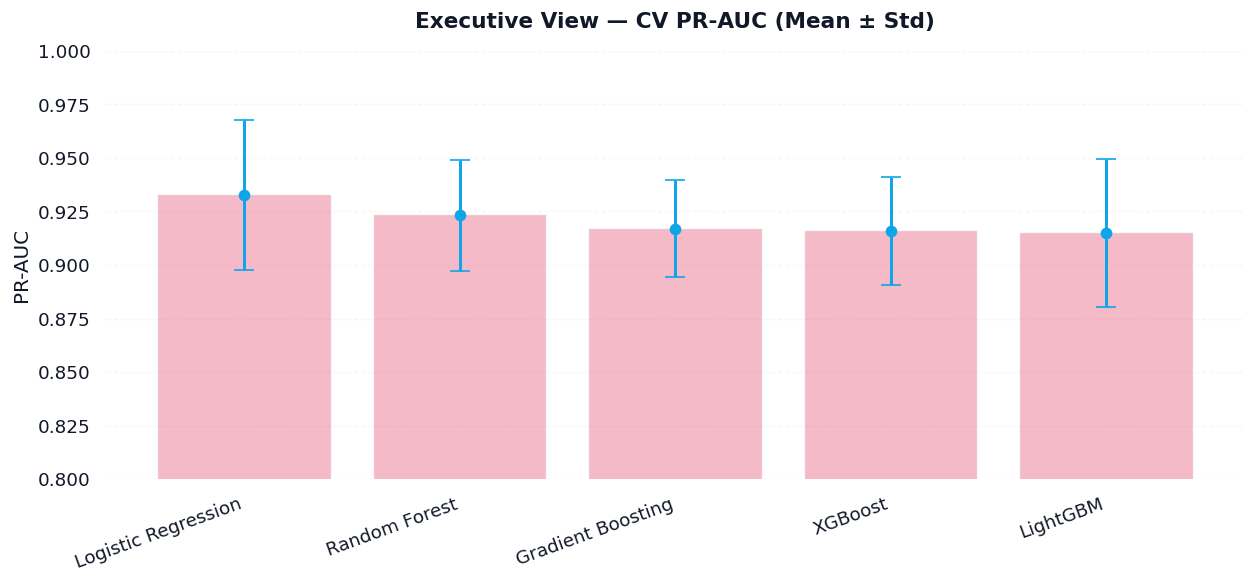

In [13]:
def plot_cv_prauc(scorecard):
    dfp = scorecard.copy()

    fig, ax = plt.subplots(figsize=(10.6, 5.0))
    x = np.arange(len(dfp))

    ax.bar(
        x,
        dfp["CV_PR-AUC_Mean"],
        color=THEME["class_yes"],  
        alpha=0.30,
        edgecolor=THEME["grid"],
        linewidth=1.0
    )

    ax.errorbar(
        x,
        dfp["CV_PR-AUC_Mean"],
        yerr=dfp["CV_PR-AUC_Std"],
        fmt="o",
        color=THEME["class_no"],    
        capsize=6,
        linewidth=1.8
    )

    ax.set_xticks(x)
    ax.set_xticklabels(dfp["Model"], rotation=20, ha="right")
    ax.set_ylim(0.80, 1.00)

    ax_title(ax, "Executive View — CV PR-AUC (Mean ± Std)")
    ax.set_ylabel("PR-AUC")

    faint_dashed_ygrid(ax, alpha=0.35, lw=0.8)
    remove_spines(ax)

    plt.tight_layout()
    plt.show()

plot_cv_prauc(scorecard)

# 🎯 8. TUNING + ENSABLE 

In [14]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="The total space of parameters .* is smaller than n_iter=.*",
    category=UserWarning
)


def render_tabs(tabs, width_px=1100):
    """
    tabs: list of (label:str, html_content:str)
    """
    panel_id = f"tabs_{uuid.uuid4().hex[:8]}"

    buttons_html = ""
    panes_html = ""
    for i, (label, content) in enumerate(tabs):
        active = "active" if i == 0 else ""
        pane_id = f"{panel_id}_pane_{i}"
        buttons_html += f'<button class="ht-tab {active}" onclick="openTab_{panel_id}(event, \'{pane_id}\')">{label}</button>'
        panes_html += f'<div class="ht-pane {active}" id="{pane_id}">{content}</div>'

    html = f"""
    <div id="{panel_id}" class="ht-wrap">
      <div class="ht-tabs">{buttons_html}</div>
      <div class="ht-content">{panes_html}</div>
    </div>

    <style>
      #{panel_id}.ht-wrap {{
        margin-top: 8px;
        border: 1px solid rgba(17,24,39,.10);
        border-radius: 12px;
        overflow: hidden;
        background: #ffffff;
      }}
      #{panel_id} .ht-tabs {{
        display: flex;
        flex-wrap: wrap;
        gap: 6px;
        padding: 10px 10px;
        border-bottom: 1px solid rgba(17,24,39,.10);
        background: #ffffff;
      }}
      #{panel_id} .ht-tab {{
        appearance: none;
        border: 1px solid rgba(17,24,39,.15);
        background: #ffffff;
        color: #111827;
        font-weight: 900;
        font-size: 12px;
        padding: 6px 10px;
        border-radius: 10px;
        cursor: pointer;
        line-height: 1.1;
      }}
      #{panel_id} .ht-tab.active {{
        background: rgba(79,70,229,.08);
        border-color: rgba(79,70,229,.35);
      }}
      #{panel_id} .ht-content {{
        padding: 10px 12px 14px 12px;
        background: #ffffff;
        max-width: 100%;
        overflow-x: auto;
        overflow-y: hidden;
      }}
      #{panel_id} .ht-pane {{ display: none; }}
      #{panel_id} .ht-pane.active {{ display: block; }}

      /* ensure tables fit and are centered */
      #{panel_id} table {{
        width: 100% !important;
        max-width: 100% !important;
        margin-left: auto !important;
        margin-right: auto !important;
      }}
      #{panel_id} th, #{panel_id} td {{
        font-size: 12px !important;
      }}
    </style>

    <script>
    function openTab_{panel_id}(evt, paneId) {{
      const root = document.getElementById("{panel_id}");
      const panes = root.getElementsByClassName("ht-pane");
      for (let i = 0; i < panes.length; i++) panes[i].classList.remove("active");

      const tabs = root.getElementsByClassName("ht-tab");
      for (let i = 0; i < tabs.length; i++) tabs[i].classList.remove("active");

      document.getElementById(paneId).classList.add("active");
      evt.currentTarget.classList.add("active");
    }}
    </script>
    """
    display(HTML(html))

def _styled_html(df_in, title, head=200, precision=6, heat=True):
    sty = df_in.head(head).style.format(precision=precision)
    if heat:
        sty = sty.background_gradient(cmap=heart_cmap, axis=None)
    sty = sty.set_caption(title)
    sty = style_heart_table(sty)
    return sty.to_html()

best_model_name = scorecard.loc[0, "Model"]

def get_tuning_space(model_name):
    if model_name == "Logistic Regression":
        base = LogisticRegression(max_iter=7000, solver="liblinear", class_weight="balanced", random_state=SEED)
        grid = {"model__penalty": ["l1","l2"], "model__C": np.logspace(-3, 2, 14)}
        return base, grid

    if model_name == "Random Forest":
        base = RandomForestClassifier(n_jobs=-1, random_state=SEED, class_weight="balanced_subsample")
        grid = {
            "model__n_estimators": [400, 700, 1000, 1400],
            "model__max_depth": [None, 10, 20, 30, 40],
            "model__min_samples_split": [2, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 4, 6],
            "model__max_features": ["sqrt", "log2"]
        }
        return base, grid

    if model_name == "Gradient Boosting":
        base = GradientBoostingClassifier(random_state=SEED)
        grid = {
            "model__n_estimators":[200,400,800],
            "model__learning_rate":[0.01,0.05,0.1],
            "model__max_depth":[2,3,4]
        }
        return base, grid

    if model_name == "XGBoost" and XGB_AVAILABLE:
        base = XGBClassifier(random_state=SEED, eval_metric="logloss", n_jobs=-1)
        grid = {
            "model__n_estimators":[400,700,1000],
            "model__max_depth":[3,4,5,6],
            "model__learning_rate":[0.01,0.03,0.05,0.1],
            "model__subsample":[0.8,0.9,1.0],
            "model__colsample_bytree":[0.8,0.9,1.0],
            "model__reg_lambda":[0.5,1.0,2.0]
        }
        return base, grid

    if model_name == "LightGBM" and LGBM_AVAILABLE:
        base = LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1, class_weight="balanced")
        grid = {
            "model__n_estimators":[600,900,1200],
            "model__learning_rate":[0.01,0.03,0.05,0.1],
            "model__num_leaves":[31,63,127],
            "model__max_depth":[-1,3,5,7,9],
            "model__subsample":[0.8,0.9,1.0],
            "model__colsample_bytree":[0.8,0.9,1.0]
        }
        return base, grid

    base = LogisticRegression(max_iter=7000, solver="liblinear", class_weight="balanced", random_state=SEED)
    grid = {"model__penalty": ["l1","l2"], "model__C": np.logspace(-3, 2, 14)}
    return base, grid

base_model, param_grid = get_tuning_space(best_model_name)
tuning_pipe = Pipeline(steps=[("prep", preprocessor), ("model", base_model)])

rs = RandomizedSearchCV(
    estimator=tuning_pipe,
    param_distributions=param_grid,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=SEED,
    verbose=0
)
rs.fit(X_train, y_train)

tuned_model = rs.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]
tuned_metrics = compute_metrics(y_test, y_pred_tuned, y_proba_tuned)

best_params_df = pd.DataFrame([rs.best_params_]).T.reset_index()
best_params_df.columns = ["param", "value"]

tuned_metrics_df = pd.DataFrame([{
    "Model": f"Tuned {best_model_name}",
    **tuned_metrics,
    "Best_CV_ROC-AUC": rs.best_score_
}])

top3 = scorecard["Model"].head(3).tolist()
estimators = [(r["name"], r["pipeline"]) for r in results if r["name"] in top3]

ensemble_model = None
ensemble_metrics = None
ensemble_metrics_df = None

if len(estimators) >= 2:
    ensemble_model = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
    ensemble_model.fit(X_train, y_train)
    y_pred_ens = ensemble_model.predict(X_test)
    y_proba_ens = ensemble_model.predict_proba(X_test)[:, 1]
    ensemble_metrics = compute_metrics(y_test, y_pred_ens, y_proba_ens)
    ensemble_metrics_df = pd.DataFrame([{"Model": f"Soft Voting (Top-{len(estimators)})", **ensemble_metrics}])


final_model = tuned_model
final_tag = f"Tuned {best_model_name}"
final_pred = y_pred_tuned
final_proba = y_proba_tuned

if ensemble_metrics is not None:
    if (ensemble_metrics["PR-AUC"] > tuned_metrics["PR-AUC"] + 1e-6) or \
       (ensemble_metrics["ROC-AUC"] > tuned_metrics["ROC-AUC"] + 1e-6):
        final_model = ensemble_model
        final_tag = f"Soft Voting (Top-{len(estimators)})"
        final_pred = y_pred_ens
        final_proba = y_proba_ens

kpi_cards([
    {"title":"Final Selected Model", "value":final_tag, "accent":THEME["indigo"]},
    {"title":"Test ROC-AUC", "value":f"{roc_auc_score(y_test, final_proba):.3f}", "accent":THEME["class_yes"]},  # ✅ red
    {"title":"Test PR-AUC", "value":f"{average_precision_score(y_test, final_proba):.3f}", "accent":THEME["class_no"]},   # ✅ blue
])

tabs = []
tabs.append(("Best Params", _styled_html(best_params_df, f"Best Parameters — Tuned {best_model_name}", head=120, precision=6, heat=True)))
tabs.append(("Tuned Metrics", _styled_html(tuned_metrics_df, "Tuned Model — Test Metrics", head=10, precision=4, heat=True)))

if ensemble_metrics_df is not None:
    tabs.append(("Ensemble Metrics", _styled_html(ensemble_metrics_df, "Ensemble — Test Metrics", head=10, precision=4, heat=True)))
else:
    tabs.append(("Ensemble Metrics", f"""
    <div style="padding:10px 4px; color:{THEME['text']}; font-weight:800;">
      Ensemble not generated (need at least 2 estimators in Top-3).
    </div>
    """))

search_summary = pd.DataFrame([{
    "BestModelName": best_model_name,
    "SearchIters": rs.n_iter,
    "CVFolds": cv.get_n_splits(),
    "Scoring": rs.scoring,
}])
tabs.append(("Search Summary", _styled_html(search_summary, "Randomized Search Summary", head=10, precision=0, heat=False)))

render_tabs(tabs, width_px=1100)

# 📈 9. REPORT


────────────────────────────────────────────────────────────────────────────────────────
DETAILED CLASSIFICATION REPORT  |  Final Model: Soft Voting (Top-3)
────────────────────────────────────────────────────────────────────────────────────────


,Label,precision,recall,f1-score,support
0,No Disease,0.8889,0.8780,0.8834,82.0000
1,Disease,0.9029,0.9118,0.9073,102.0000
2,accuracy,0.8967,0.8967,0.8967,0.8967
3,macro avg,0.8959,0.8949,0.8954,184.0000
4,weighted avg,0.8967,0.8967,0.8967,184.0000


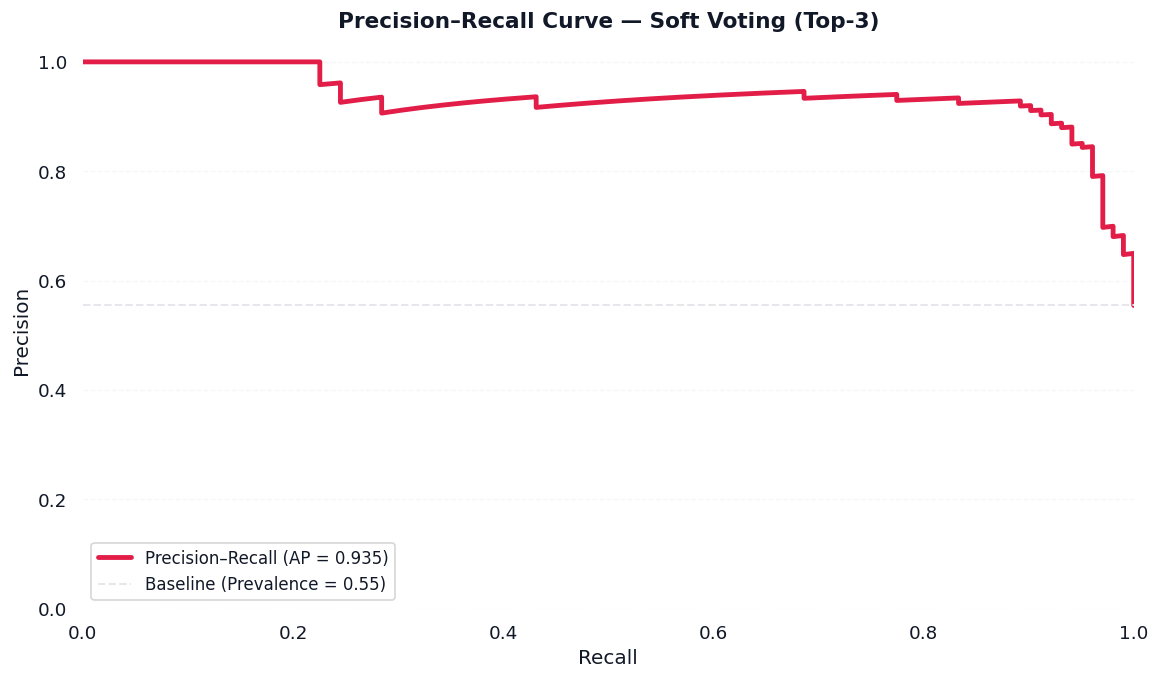

In [15]:
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score

print("\n" + "─"*88)
print(f"DETAILED CLASSIFICATION REPORT  |  Final Model: {final_tag}")
print("─"*88)

report_dict = classification_report(
    y_test,
    final_pred,
    target_names=["No Disease", "Disease"],
    zero_division=0,
    output_dict=True
)

report_df = (
    pd.DataFrame(report_dict)
    .T.reset_index()
    .rename(columns={"index": "Label"})
)

report_df["Label"] = report_df["Label"].astype(str)

order = ["No Disease", "Disease", "accuracy", "macro avg", "weighted avg"]
report_df["_ord"] = report_df["Label"].map({k: i for i, k in enumerate(order)}).fillna(999).astype(int)
report_df = report_df.sort_values("_ord").drop(columns="_ord")

num_cols = ["precision", "recall", "f1-score", "support"]
for c in num_cols:
    if c in report_df.columns:
        report_df[c] = pd.to_numeric(report_df[c], errors="coerce")

show_df(
    report_df[["Label", "precision", "recall", "f1-score", "support"]],
    title=f"Classification Report — {final_tag}",
    head=10,
    precision=4,
    heat=True
)

prec, rec, _ = precision_recall_curve(y_test, final_proba)
ap = average_precision_score(y_test, final_proba)

fig, ax = plt.subplots(figsize=(9.8, 5.8))
hatch_panel(ax, alpha=0.05, hatch="///")

ax.plot(
    rec, prec,
    linewidth=2.9,
    color=THEME["class_yes"],
    label=f"Precision–Recall (AP = {ap:.3f})"
)

base_rate = float(np.mean(y_test))
ax.hlines(
    base_rate, xmin=0, xmax=1,
    colors=THEME["grid"],
    linestyles="--",
    linewidth=1.2,
    label=f"Baseline (Prevalence = {base_rate:.2f})"
)

ax_title(ax, f"Precision–Recall Curve — {final_tag}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.02)

faint_dashed_ygrid(ax, alpha=0.32, lw=0.8)
remove_spines(ax)

ax.legend(loc="lower left", frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

# 🔮 10. FEATURE IMPORTANCE (SHAP VALUES)

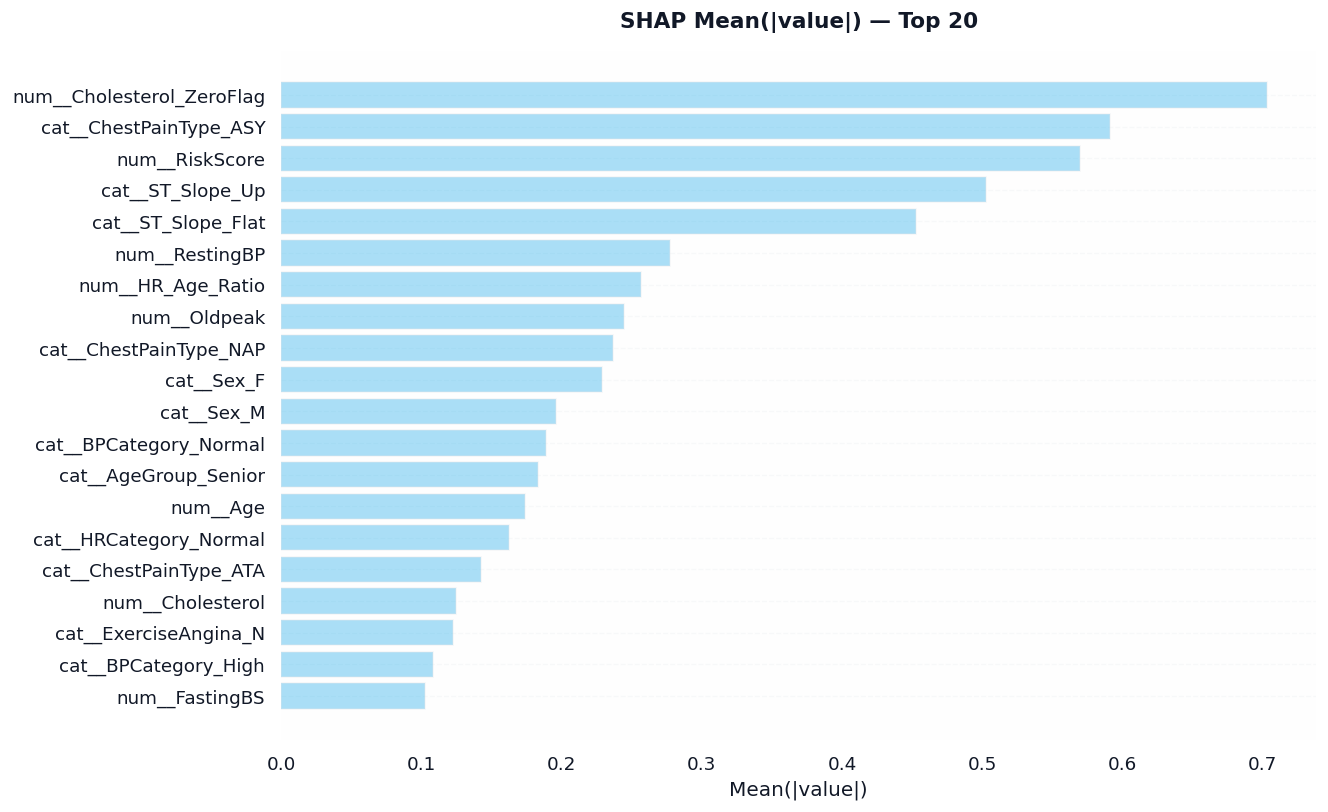

In [16]:


def ensure_pipeline_for_explainability(model_obj, preprocessor):
    """
    Returns a Pipeline with named_steps['prep'] and named_steps['model'] guaranteed.
    Handles VotingClassifier and bare estimators safely.
    """
    name = model_obj.__class__.__name__.lower()

    if name.startswith("voting"):
        try:
            est0 = model_obj.estimators_[0]
            cand = est0[1] if isinstance(est0, tuple) else est0

            if hasattr(cand, "named_steps") and "prep" in cand.named_steps and "model" in cand.named_steps:
                return cand

            return Pipeline([("prep", preprocessor), ("model", cand)])
        except Exception:
            return Pipeline([("prep", preprocessor), ("model", model_obj)])

    if hasattr(model_obj, "named_steps") and "prep" in getattr(model_obj, "named_steps", {}) and "model" in model_obj.named_steps:
        return model_obj

    return Pipeline([("prep", preprocessor), ("model", model_obj)])


def get_feature_names(prep):
    try:
        return np.array(prep.get_feature_names_out(), dtype=object)
    except Exception:
        return None

def transform_X(pipe, X):
    Xt = pipe.named_steps["prep"].transform(X)
    if hasattr(Xt, "toarray"):
        Xt = Xt.toarray()
    return Xt


def plot_shap_bar_only(imp_df, title="SHAP Mean(|value|) — Top 20", topn=20):
    top = imp_df.sort_values("importance", ascending=False).head(topn).iloc[::-1]

    fig, ax = plt.subplots(figsize=(11.2, 6.9))

    ax.set_facecolor("#f3f4f6")
    ax.patch.set_hatch("///")
    ax.patch.set_edgecolor("none")
    ax.patch.set_alpha(0.05)

    ax.barh(
        top["feature"],
        top["importance"],
        color=THEME["class_no"],  
        alpha=0.35,
        edgecolor=THEME["grid"],
        linewidth=1.0
    )

    ax_title(ax, title)
    ax.set_xlabel("Mean(|value|)")
    ax.set_ylabel("")

    faint_dashed_ygrid(ax, alpha=0.26, lw=0.8)
    remove_spines(ax)

    plt.tight_layout()
    plt.show()
    plt.close("all")


def explainability_bar_only(final_model, preprocessor, X_test, y_test, seed=42, topn=20):
    """
    Builds importance DF internally (SHAP if available, else permutation),
    then plots ONLY bar chart (no DF output) to keep notebook lightweight.
    """
    explain_pipe = ensure_pipeline_for_explainability(final_model, preprocessor)
    prep = explain_pipe.named_steps["prep"]
    core_model = explain_pipe.named_steps["model"]

    feature_names = get_feature_names(prep)
    X_test_t = transform_X(explain_pipe, X_test)

    imp_df = None
    used = None

    if "SHAP_AVAILABLE" in globals() and SHAP_AVAILABLE:
        try:
            model_name = core_model.__class__.__name__.lower()
            is_tree = any(k in model_name for k in ["forest", "xgb", "lgbm", "gradientboost", "gbm", "tree"])

            if is_tree:
                explainer = shap.TreeExplainer(core_model)
                shap_values = explainer.shap_values(X_test_t)

                sv = shap_values[1] if isinstance(shap_values, list) else shap_values
                shap_imp = np.abs(sv).mean(axis=0)

            else:
                explainer = shap.Explainer(core_model, X_test_t, feature_names=feature_names)
                sv = explainer(X_test_t)
                shap_imp = np.abs(sv.values).mean(axis=0)

            feats = feature_names if (feature_names is not None and len(feature_names) == len(shap_imp)) \
                   else np.array([f"f_{i}" for i in range(len(shap_imp))], dtype=object)

            imp_df = pd.DataFrame({"feature": feats, "importance": shap_imp}).sort_values("importance", ascending=False)
            used = "SHAP"

        except Exception as e:
            imp_df = None

    if imp_df is None:
        perm = permutation_importance(
            core_model, X_test_t, y_test,
            n_repeats=12,
            random_state=seed,
            scoring="roc_auc",
            n_jobs=-1
        )
        pi = perm.importances_mean
        feats = feature_names if (feature_names is not None and len(feature_names) == len(pi)) \
               else np.array([f"f_{i}" for i in range(len(pi))], dtype=object)
        imp_df = pd.DataFrame({"feature": feats, "importance": pi}).sort_values("importance", ascending=False)
        used = "Permutation"

    title = "SHAP Mean(|value|) — Top 20" if used == "SHAP" else "Permutation Importance (ROC-AUC) — Top 20"
    plot_shap_bar_only(imp_df, title=title, topn=topn)

    try:
        del X_test_t
    except Exception:
        pass
    gc.collect()

    return imp_df, used


imp_df, used_method = explainability_bar_only(
    final_model=final_model,
    preprocessor=preprocessor,
    X_test=X_test,
    y_test=y_test,
    seed=SEED,
    topn=20
)

# 💡 11. EXCUTIVE SUMMARY

In [17]:
final_summary = pd.DataFrame([{
    "DatasetRows": int(df.shape[0]),
    "DatasetCols": int(df.shape[1]),
    "CholesterolZeros": int(chol_zero),
    "TargetPositiveRate": float(df["HeartDisease"].mean()),
    "FinalModel": final_tag,
    "Test_ROC-AUC": float(roc_auc_score(y_test, final_proba)),
    "Test_PR-AUC": float(average_precision_score(y_test, final_proba)),
    "Test_Accuracy": float(accuracy_score(y_test, final_pred)),
    "Test_F1": float(f1_score(y_test, final_pred, zero_division=0)),
    "Test_Recall": float(recall_score(y_test, final_pred, zero_division=0)),
    "Test_Precision": float(precision_score(y_test, final_pred, zero_division=0)),
}])

show_df(final_summary, "Executive Summary (Final)", head=5, precision=4)

,DatasetRows,DatasetCols,CholesterolZeros,TargetPositiveRate,FinalModel,Test_ROC-AUC,Test_PR-AUC,Test_Accuracy,Test_F1,Test_Recall,Test_Precision
0,918,12,172,0.5534,Soft Voting (Top-3),0.9354,0.9354,0.8967,0.9073,0.9118,0.9029


<div style="
  background: linear-gradient(to right, #f8fafc, #f1f5f9);
  padding: 25px;
  border-radius: 12px;
  color: #1e293b;
  font-family: 'Segoe UI', Roboto, Arial, sans-serif;
  font-size: 16px;
  line-height: 1.7;
  box-shadow: 0 4px 15px rgba(15,23,42,0.1);
  margin-top: 30px;
  border: 1px solid #cbd5e1;
">

  <h2 style="color: #e11d48; margin-top: 0; display: flex; align-items: center; gap: 10px;">
    ❤️ Support & Feedback
  </h2>

  <p>
    If this <strong>Heart Failure Analysis</strong> notebook helped you uncover clinical insights or 
    inspired your own predictive modeling, you can support this research by:
  </p>

  <ul style="list-style-type: none; padding-left: 5px;">
    <li style="margin-bottom: 10px;">⭐ <strong>Upvoting</strong> the notebook to improve its visibility for the healthcare data community</li>
    <li style="margin-bottom: 10px;">💬 <strong>Leaving a comment</strong> — sharing your thoughts, clinical questions, or suggestions for new features</li>
    <li style="margin-bottom: 10px;">🔁 <strong>Forking</strong> the project to extend the survival analysis, add medical visualizations, or test your own tuned algorithms</li>
  </ul>

  <p>
    Your engagement helps keep this kind of open, data-driven storytelling around 
    <strong>cardiovascular health</strong> evolving and improving 💡
  </p>

  <blockquote style="
    background-color: #fff1f2;
    border-left: 5px solid #e11d48;
    padding: 15px 20px;
    margin-top: 20px;
    font-style: italic;
    color: #9f1239;
    border-radius: 0 8px 8px 0;">
    Analyze deeply, predict accurately, and may your medical models stay robust and interpretable. 🩺📊
  </blockquote>

</div>